# Loss reserving as a prediction problem — quickstart

**Loss reserving, reframed.** A loss triangle is the actuarial object nobody treats as tabular: accident
years down the side, development periods across the top, and a lower-right half that is unknown — and *that
unknown half is the reserve*. This notebook turns it into a supervised prediction problem and hands it to
**TabPFN-3.5**, which returns the reserve **with its whole predictive distribution** in a single forward pass
on a CPU. No tuning, no API calls.

**Read this before the numbers.** The *distribution* is the deliverable. The **point estimate is not
competitive**: over 464 paired evaluations on the CAS Loss Reserve Database it was closer than Chain Ladder
on 38.8% of triangles (`results/fleet/FINDINGS.md`). Use this to see a reserve distribution, not to produce a
reserve. The calibration of those intervals is measured and it under-covers — that is written down rather than
hidden.

Nothing below was tuned for this triangle. That is the claim being tested, not a convenience.

In [1]:
# In Colab:  !git clone https://github.com/IFoA-ADSWP/tabpfn-reserving && cd tabpfn-reserving && pip install -e .
# Locally:   pip install -e .
# The first run downloads the TabPFN-3.5 weights; TABPFN_TOKEN is read from ~/.config/tfm/keys.env if set.
import warnings

import numpy as np

warnings.filterwarnings("ignore")   # a quickstart should not open with a library warning

from tabpfn_reserving import arm
from tabpfn_reserving.triangle import (Triangle, chainladder_baseline, direct_training_rows,
                                       factor_reserve)

TRIANGLE = "abc"     # any bundled CAS sample: abc, genins, mcl, ukmotor, ...

## 1. The triangle, as a triangle

Every `·` below is a cell nobody has observed yet. Those cells are not missing data — they are the thing the
reserve is a prediction of.

In [2]:
tri = Triangle.load(TRIANGLE)
print(f"{tri.name}: {tri.n} accident years x {tri.n} development periods")
print(f"development ages: {tri.ages[0]}..{tri.ages[-1]} months\n")
for a in range(tri.n):
    row = " ".join(f"{v:>9,.0f}" if np.isfinite(v) else "        ·" for v in tri.values[a])
    print(f"  {tri.origin[a][:7]:<8} {row}")

abc: 11 accident years x 11 development periods
development ages: 12..132 months

  1977       153,638   342,050   476,584   564,040   624,388   666,792   698,030   719,282   735,904   750,344   762,544
  1978       178,536   404,948   563,842   668,528   739,976   787,966   823,542   848,360   871,022   889,022         ·
  1979       210,172   469,340   657,728   780,802   864,182   920,268   958,764   992,532 1,019,932         ·         ·
  1980       211,448   464,930   648,300   779,340   858,334   918,566   964,134 1,002,134         ·         ·         ·
  1981       219,810   486,114   680,764   800,862   888,444   951,194 1,002,194         ·         ·         ·         ·
  1982       205,654   458,400   635,906   765,428   862,214   944,614         ·         ·         ·         ·         ·
  1983       197,716   453,124   647,772   790,100   895,700         ·         ·         ·         ·         ·         ·
  1984       239,784   569,026   833,828 1,024,228         ·         · 

## 2. The baseline, on the same cells

Before comparing anything to Chain Ladder, this repository's hand-written Chain Ladder has to reproduce the
Casualty Actuarial Society's own package. If it did not, every comparison afterwards would be between two
methods that are not measuring the same thing.

In [3]:
anchor = tri.n - 1
gf = tri.global_factors(tri.known(anchor))
ours = factor_reserve(tri, anchor, gf)
theirs = chainladder_baseline(tri, anchor)["chainladder_ibnr"]
print(f"observed cells        {int(tri.known(anchor).sum())} of {tri.n ** 2}")
print(f"our Chain Ladder      {ours:>14,.0f}")
print(f"the CAS package's own {theirs:>14,.0f}")
print(f"agreement             {'exact' if abs(ours - theirs) < 1e-6 else f'DIFFERS by {ours - theirs:,.2f}'}")

observed cells        66 of 121


our Chain Ladder           5,277,760
the CAS package's own      5,277,760
agreement             exact


## 3. The reserve, and its distribution

The model predicts each accident year's whole remaining development in **one row**, with the *horizon* as a
feature — no recursion, so nothing it predicts is fed back in. The prediction is a ratio to Chain Ladder's own
projection ("delta"), which means the model only has to learn a *correction* to the incumbent.

Note what that implies for reading the result below: with a Chain-Ladder-relative target, an arm predicting a
correction of exactly 1.0 reproduces Chain Ladder. Agreement is therefore partly by construction.

In [4]:
X, y = direct_training_rows(tri, list(range(2, tri.n - 2)), target="delta")
print(f"training rows: {len(y)} — one per (earlier valuation date, accident year) pair")
print("(the horizon only varies across valuation dates, so that is what gives the model horizons to learn)\n")

model = arm.make_model("local").fit(X, y)
out = arm.reserve_direct(model, tri, anchor, 300, np.random.default_rng(0), target="delta")
print(f"reserve (one prediction per accident year): {out['reserve']:,.0f}")

training rows: 42 — one per (earlier valuation date, accident year) pair
(the horizon only varies across valuation dates, so that is what gives the model horizons to learn)



reserve (one prediction per accident year): 5,269,218


## 4. Three summaries of the same object, and why they are printed separately

"Reserve" is ambiguous. The point figure compounds per-accident-year predictions; the mean and median come
from the sampled paths. In the recursive arm those disagreed by 32%, which is how an inconsistency went
unnoticed; here they are labelled.

In [5]:
s = out["samples"]
point = out["reserve"]
print(f"compounded point      {point:>14,.0f}")
print(f"sampled mean          {out['reserve_mean']:>14,.0f}   "
      f"{100 * (out['reserve_mean'] - point) / point:+.1f}% vs the point")
print(f"sampled median        {out['reserve_median']:>14,.0f}   "
      f"{100 * (out['reserve_median'] - point) / point:+.1f}% vs the point")
print(f"Chain Ladder          {ours:>14,.0f}   the incumbent, like-for-like on the same cells")
print()
for q in (0.05, 0.25, 0.5, 0.75, 0.95, 0.99):
    print(f"  p{int(q * 100):<3} {np.quantile(s, q):>14,.0f}")
print(f"\ndistribution route: {out['distribution_route']} quantiles, "
      f"{out['draws_method']} draws, 300 of them")
print("a 300-draw p99 is carried by roughly the top 3 draws — it is not a number to quote to the pound")

compounded point           5,269,218
sampled mean               5,362,130   +1.8% vs the point
sampled median             5,639,539   +7.0% vs the point
Chain Ladder               5,277,760   the incumbent, like-for-like on the same cells

  p5        2,442,459
  p25       4,727,508
  p50       5,639,539
  p75       6,190,702
  p95       7,507,848
  p99       9,999,697

distribution route: exact quantiles, bar-bins draws, 300 of them
a 300-draw p99 is carried by roughly the top 3 draws — it is not a number to quote to the pound


## 5. The picture the claim rests on

A reserve is not a number, it is a distribution — because what gets used downstream is a *quantile*: a risk
margin, an IFRS 17 risk adjustment, a Solvency II capital figure. The x-axis is logarithmic: the distribution
is strongly right-skewed and a linear axis would crush every draw but the handful in the tail into one bar.

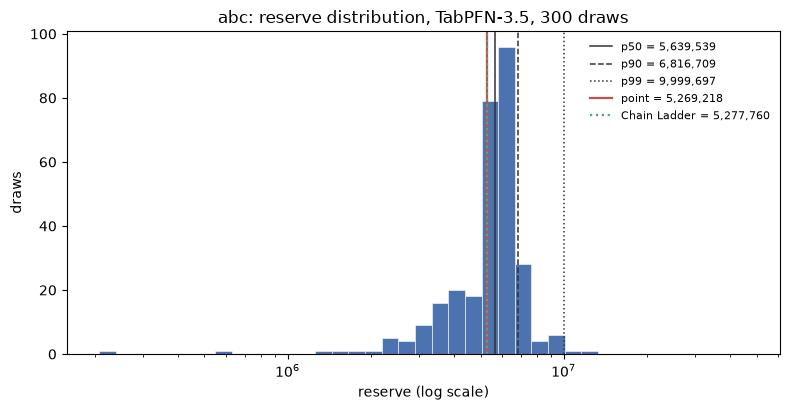

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.set_xscale("log")
pos = s[np.isfinite(s) & (s > 0)]
ax.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40),
        color="#4C72B0", edgecolor="white", linewidth=0.4)
for q, style in ((0.5, "-"), (0.9, "--"), (0.99, ":")):
    ax.axvline(np.quantile(s, q), color="#333", linestyle=style, linewidth=1.1,
               label=f"p{int(q * 100)} = {np.quantile(s, q):,.0f}")
ax.axvline(point, color="#C44E52", linewidth=1.6, label=f"point = {point:,.0f}")
ax.axvline(ours, color="#55A868", linewidth=1.6, linestyle=":", label=f"Chain Ladder = {ours:,.0f}")
ax.set_xlabel("reserve (log scale)")
ax.set_ylabel("draws")
ax.set_title(f"{tri.name}: reserve distribution, TabPFN-3.5, 300 draws")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## What this shows, and what it does not

**Shown here.** A triangle becomes a prediction problem; the model's own bar distribution gives a reserve
distribution in one forward pass; the arithmetic underneath reproduces the CAS package exactly, which is what
makes the comparison meaningful at all.

**Not shown, and measured elsewhere in the repository:**

- **The point estimate loses.** Over 464 fleet evaluations it is closer than Chain Ladder on 38.8% of
  triangles, moving the reserve by a median of 142% of Chain Ladder's. `results/fleet/FINDINGS.md`.
- **Why it fails is known.** Predicting a triangle step by step feeds the model its own answers, and its
  per-step bias is zero where it has training examples and **+3.2% per step** where it extrapolates —
  compounding to ×1.33 over nine steps. Deleting the recursion removed the compounding entirely (+66.8% →
  −1.2% on `abc`). `results/runs/20260918-023600_depth-bias/FINDINGS.md`.
- **Calibration is poor.** The intervals under-cover at every nominal level, and not because they are narrow.
- **A trap worth knowing if you build your own backtest.** Anchored near the ultimate, the deepest measurable
  step is two periods and that bias reads −0.0018 (se 0.0030) — flat, and the effect looks absent. Anchored
  nine years back it reads +0.0190 (se 0.0016). A short validation window will tell you a recursive model is
  fine when it is not.
- **No tail factor**, and per-cell draws are independent in the recursive arm.

The honest summary: this is a working way to get a *distribution* out of a triangle with no tuning, and a
measurement of where that approach stops working.